In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [174]:
df = pd.read_csv('../csv/bigmart.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [175]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [176]:
mean_weight = df['Item_Weight'].mean()

In [177]:
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

In [178]:
mode_size = df['Outlet_Size'].mode()[0]

In [179]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size)

In [180]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [181]:
df = pd.get_dummies(df.drop(['Item_Identifier'], axis=1), dtype=int)

In [182]:
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
1,5.92,0.019278,48.2692,2009,443.4228,0,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
2,17.50,0.016760,141.6180,1999,2097.2700,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
3,19.20,0.000000,182.0950,1998,732.3800,0,0,1,0,0,...,0,1,0,0,0,1,1,0,0,0
4,8.93,0.000000,53.8614,1987,994.7052,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0


In [183]:
df.isnull().sum()

Item_Weight                        0
Item_Visibility                    0
Item_MRP                           0
Outlet_Establishment_Year          0
Item_Outlet_Sales                  0
Item_Fat_Content_LF                0
Item_Fat_Content_Low Fat           0
Item_Fat_Content_Regular           0
Item_Fat_Content_low fat           0
Item_Fat_Content_reg               0
Item_Type_Baking Goods             0
Item_Type_Breads                   0
Item_Type_Breakfast                0
Item_Type_Canned                   0
Item_Type_Dairy                    0
Item_Type_Frozen Foods             0
Item_Type_Fruits and Vegetables    0
Item_Type_Hard Drinks              0
Item_Type_Health and Hygiene       0
Item_Type_Household                0
Item_Type_Meat                     0
Item_Type_Others                   0
Item_Type_Seafood                  0
Item_Type_Snack Foods              0
Item_Type_Soft Drinks              0
Item_Type_Starchy Foods            0
Outlet_Identifier_OUT010           0
O

In [184]:
df_reg = df.copy(deep=True)

In [185]:
x = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']
x.shape, y.shape

((8523, 45), (8523,))

In [186]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# x_scaled = scaler.fit_transform(x)

In [187]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)

In [188]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [189]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [190]:
train_predictions = lr.predict(x_train)
k = mean_absolute_error(train_predictions, y_train)
print(f"Train MAE: {k}")

Train MAE: 838.0101302566184


In [191]:
test_predictions = lr.predict(x_test)
k = mean_absolute_error(test_predictions, y_test)
print(f"Test MAE: {k}")

Test MAE: 828.8296476251887


In [192]:
lr.coef_

array([ 7.28557000e-01, -3.82572064e+02,  1.54621379e+01, -1.96754531e+01,
       -1.06096911e+01, -1.11820279e+01,  4.55717469e+01,  2.19724143e+01,
       -4.57524422e+01,  1.65271819e+01, -3.27789700e+01, -1.16146586e+02,
        9.86246940e+00, -6.34032520e+01, -4.47594976e+01,  2.84043988e+01,
        3.88600312e+01, -1.02339325e+01, -5.34835474e+01, -3.44198216e+01,
       -2.42284575e+01,  3.48218388e+02, -3.73337613e+01, -4.17651006e+01,
        1.66804571e+01, -6.21851564e+02, -8.76269275e+01,  5.93349387e+01,
        6.25868342e+01, -4.72037969e+02,  6.91041497e+02,  2.45802906e+02,
       -2.00793470e+02,  1.77091361e+02,  1.46452393e+02, -8.76269275e+01,
        1.36770630e+02, -4.91437020e+01, -1.48494215e+02,  1.04344375e+02,
        4.41498401e+01, -1.09388953e+03,  3.40261201e+02,  6.25868342e+01,
        6.91041497e+02])

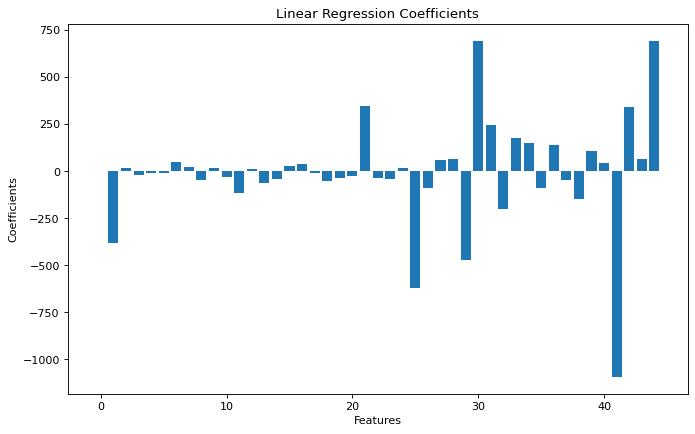

In [193]:
plt.figure(figsize=(10, 6), dpi=80, facecolor='w', edgecolor='b')
x_ax = range(len(x_train.columns))
y_ax = lr.coef_
plt.bar(x_ax, y_ax)
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title('Linear Regression Coefficients')
plt.show()

In [194]:
# We can notice that the coefficients are very small, which indicates that the model is not able to capture the relationship between the features and the target variable. This could be due to multicollinearity or other issues in the data. Further analysis and feature engineering may be required to improve the model's performance.

In [195]:
# Let's drop the features with very small coefficients and retrain the model to see if we can improve the performance.

In [196]:
coeff_df = pd.DataFrame({'Feature': x_train.columns, 'Coefficient': lr.coef_})

In [197]:
coeff_df.head(10)

,Feature,Coefficient
0,Item_Weight,0.728557
1,Item_Visibility,-382.572064
2,Item_MRP,15.462138
3,Outlet_Establishment_Year,-19.675453
4,Item_Fat_Content_LF,-10.609691
5,Item_Fat_Content_Low Fat,-11.182028
6,Item_Fat_Content_Regular,45.571747
7,Item_Fat_Content_low fat,21.972414
8,Item_Fat_Content_reg,-45.752442
9,Item_Type_Baking Goods,16.527182


In [198]:
req_features = coeff_df[coeff_df['Coefficient'] > 0.5]['Feature'].tolist()

In [199]:
# Now using these features to train the model again

In [200]:
x_train, x_test, y_train, y_test = train_test_split(x[req_features], y, test_size=0.2, random_state=50)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((6818, 22), (1705, 22), (6818,), (1705,))

In [201]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [202]:
train_predictions = lr.predict(x_train)
k = mean_absolute_error(train_predictions, y_train)
print(f"Train MAE: {k}")

Train MAE: 838.3704865433209


In [203]:
test_predictions = lr.predict(x_test)
k = mean_absolute_error(test_predictions, y_test)
print(f"Test MAE: {k}")

Test MAE: 829.1272101477772


In [204]:
# Let's do one more testing, now using regularization techniques like Ridge and Lasso to see if we can improve the performance further.

In [218]:
from sklearn.linear_model import Ridge, Lasso

In [219]:
alpha_ridge = [0, 1e-8, 1e-5, 1e-1, 1, 5, 10, 20, 25, 30, 50, 75, 100]

In [220]:
def ridge_model(train_x, train_y, test_x, test_y, alpha_list):
    for alpha in alpha_list:
        ridge = Ridge(alpha=alpha)
        ridge.fit(train_x, train_y)
        train_pred = ridge.predict(train_x)
        test_pred = ridge.predict(test_x)
        train_mae = mean_absolute_error(train_pred, train_y)
        test_mae = mean_absolute_error(test_pred, test_y)
        print(f"Alpha: {alpha}, Train MAE: {train_mae}, Test MAE: {test_mae}")

In [221]:
x_reg = df_reg.drop('Item_Outlet_Sales', axis=1)
y_reg = df_reg['Item_Outlet_Sales']
x_reg.shape, y_reg.shape

((8523, 45), (8523,))

In [222]:
from sklearn.model_selection import train_test_split
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y, test_size=0.2, random_state=50)

In [223]:
for i in range(len(alpha_ridge)):
    ridge_model(x_train_reg, y_train_reg, x_test_reg, y_test_reg, [alpha_ridge[i]])

Alpha: 0, Train MAE: 838.9729394837196, Test MAE: 830.7191813489736
Alpha: 1e-08, Train MAE: 838.0101302563573, Test MAE: 828.8296476244315
Alpha: 1e-05, Train MAE: 838.0101299957519, Test MAE: 828.8296468688513
Alpha: 0.1, Train MAE: 838.0075267879729, Test MAE: 828.8221004580164
Alpha: 1, Train MAE: 837.9845786642381, Test MAE: 828.7555779942215
Alpha: 5, Train MAE: 837.8993894076867, Test MAE: 828.485526999951
Alpha: 10, Train MAE: 837.8149581920227, Test MAE: 828.1999456048761
Alpha: 20, Train MAE: 837.6800806595362, Test MAE: 827.7280344916928
Alpha: 25, Train MAE: 837.6276249449052, Test MAE: 827.5313276839221
Alpha: 30, Train MAE: 837.5766952585814, Test MAE: 827.3542372657877
Alpha: 50, Train MAE: 837.4130440634233, Test MAE: 826.8204782187032
Alpha: 75, Train MAE: 837.3108278329332, Test MAE: 826.511818743407
Alpha: 100, Train MAE: 837.3047531439438, Test MAE: 826.4350232026144


In [224]:
# There is a very lil change in the MAE values for different alpha values, which indicates that the model is not very sensitive to the regularization parameter. This could be due to the fact that the features are not very informative and also, data is very simple and evenly distributed.